# <center> Cluster Modelling <br> Salary and Spending Scores Example</center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

There are over 100 different clustering algorithms! In this notebook, we'll start by looking at 1 of the most common methods! 
<br><center>K-Means Clustering</center> 
<br>and how to 'optimize' the output.

In this sample dataset, we have an estimated annual income and a spending score for a shopping centre. <br>How can we group these customers/clients?
<br> Is this the 'best' outcome for our client?
<br> Should we consider any other possible outcomes when presenting the final results?

## Step 1: Import Libraries

In [3]:
# Just to ignore warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pickle

## Step 2: Determine, Load and Review Dataset

In [5]:
df = pd.read_csv('..\spending.csv')

In [6]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.2 KB


In [8]:
df.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


Text(0, 0.5, 'Spending Score (1-100)')

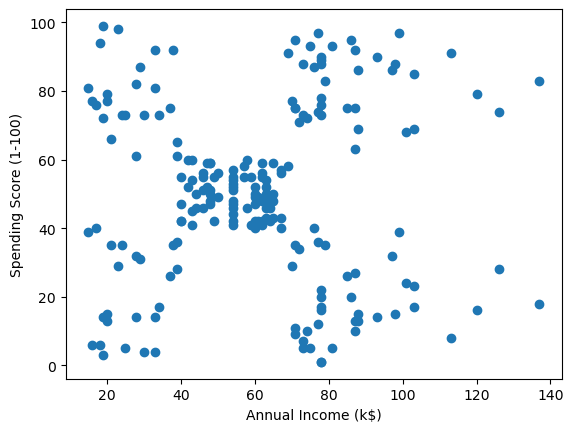

In [9]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

## Step 3: Define training data 

In [11]:
x_columns = 2
x = df.iloc[:, 0:x_columns].values

## Step 4: Create a Cluster Model

In [13]:
# Create the model with a number that might make sense based on the visualization
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 5, random_state=0)

## Step 5: Visualize the Resulting Clusters

In [15]:
# What are we predicting with this model?
## The number used to count off which objects belong in the same group!

y = model.fit_predict(x)
print(y)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


In [16]:
# Determine the Centroids for visualization
# (The output is the set of coordinates that we can use to visualize the centroid.)

centres = model.cluster_centers_
print(centres)

[[88.2        17.11428571]
 [55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [26.30434783 20.91304348]]


Text(0, 0.5, 'Spending Score (1-100)')

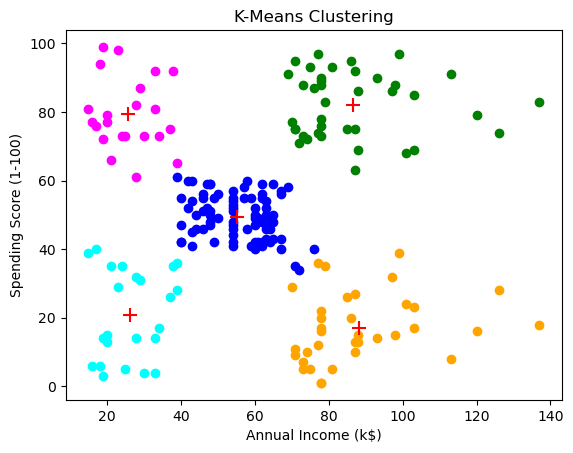

In [17]:
colors = ['orange', 'blue', 'green', 'magenta', 'cyan']
for i in range(5):
    plt.scatter(x[y == i, 0], x[y == i, 1], c=colors[i])
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], color='red', marker='+', s=100)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

## Step 6: Optimize the K-Means Model

Text(0, 0.5, 'Inertia')

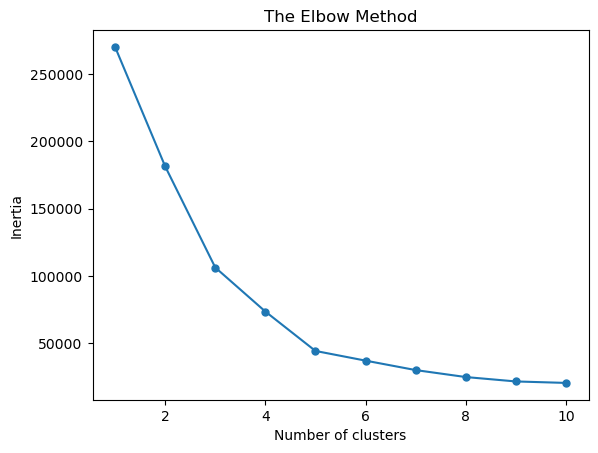

In [56]:
from sklearn.cluster import KMeans
scores = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=0)
    model.fit(x)
    scores.append(model.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 11), scores, marker='.', markersize=10)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia') # Model Inertia

In [20]:
model2 = KMeans(n_clusters=2, random_state=0)
y2 = model2.fit_predict(x)
centres2=model2.cluster_centers_

Text(0, 0.5, 'Spending Score (1-100)')

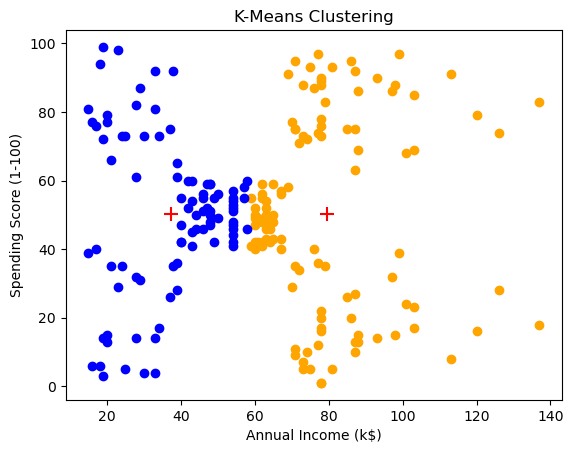

In [21]:
import matplotlib.pyplot as plt
colors = ['orange', 'blue', 'green', 'magenta', 'cyan']
for i in range(2):
    plt.scatter(x[y2 == i, 0], x[y2 == i, 1], c=colors[i])
plt.scatter(model2.cluster_centers_[:, 0], model2.cluster_centers_[:, 1], color='red', marker='+', s=100)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

In [22]:
model4 = KMeans(n_clusters=4, random_state=0)
y4 = model4.fit_predict(x)
centres4=model4.cluster_centers_

Text(0, 0.5, 'Spending Score (1-100)')

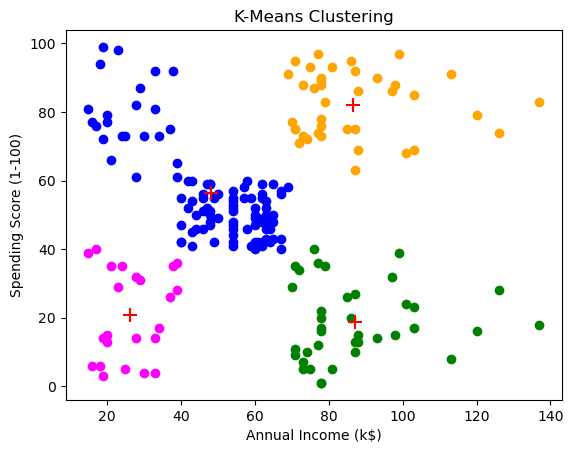

In [23]:
colors = ['orange', 'blue', 'green', 'magenta', 'cyan','yellow']
for i in range(4):
    plt.scatter(x[y4 == i, 0], x[y4 == i, 1], c=colors[i])
plt.scatter(model4.cluster_centers_[:, 0], model4.cluster_centers_[:, 1], color='red', marker='+', s=100)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

In [24]:
model6 = KMeans(n_clusters=6, random_state=0)
y6 = model6.fit_predict(x)
centres6 = model6.cluster_centers_

Text(0, 0.5, 'Spending Score (1-100)')

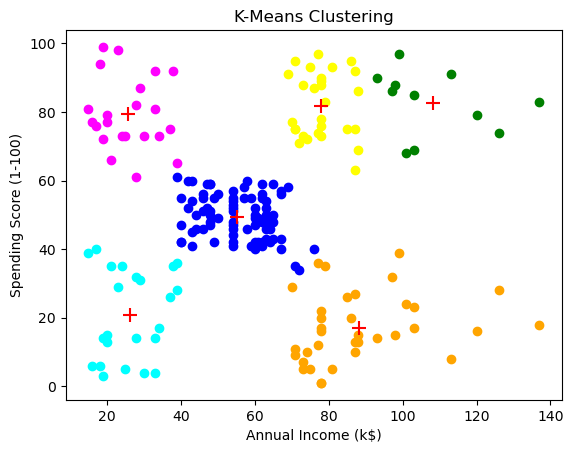

In [25]:
colors = ['orange', 'blue', 'green', 'magenta', 'cyan','yellow']
for i in range(6):
    plt.scatter(x[y6 == i, 0], x[y6 == i, 1], c=colors[i])
plt.scatter(model6.cluster_centers_[:, 0], model6.cluster_centers_[:, 1], color='red', marker='+', s=100)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

In [26]:
model5 = KMeans(n_clusters=5, random_state=0)
y5 = model5.fit_predict(x)
centres5 = model5.cluster_centers_

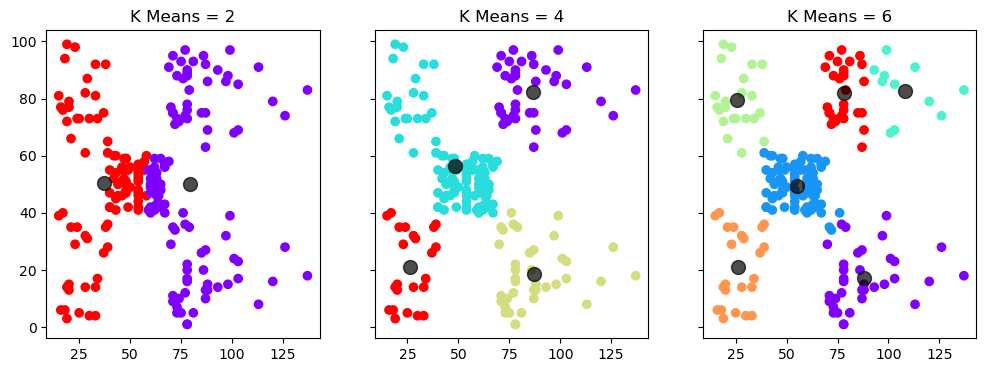

In [27]:
f, (ax1,ax2,ax3) = plt.subplots(nrows=1,ncols=3,sharey=True,figsize=(12,4))

ax1.set_title('K Means = 2')
ax1.scatter(x[:,0],x[:,1],c=model2.labels_,cmap='rainbow')
ax1.scatter(x=centres2[:,0],y=centres2[:,1],c='black',s=100,alpha=0.7)

ax2.set_title('K Means = 4')
ax2.scatter(x[:,0],x[:,1],c=model4.labels_,cmap='rainbow')
ax2.scatter(x=centres4[:,0],y=centres4[:,1],c='black',s=100,alpha=0.7)

ax3.set_title('K Means = 6')
ax3.scatter(x[:,0],x[:,1],c=model6.labels_,cmap='rainbow')
ax3.scatter(x=centres6[:,0],y=centres6[:,1],c='black',s=100,alpha=0.7)

Text(0, 0.5, 'SSE (Inertia)')

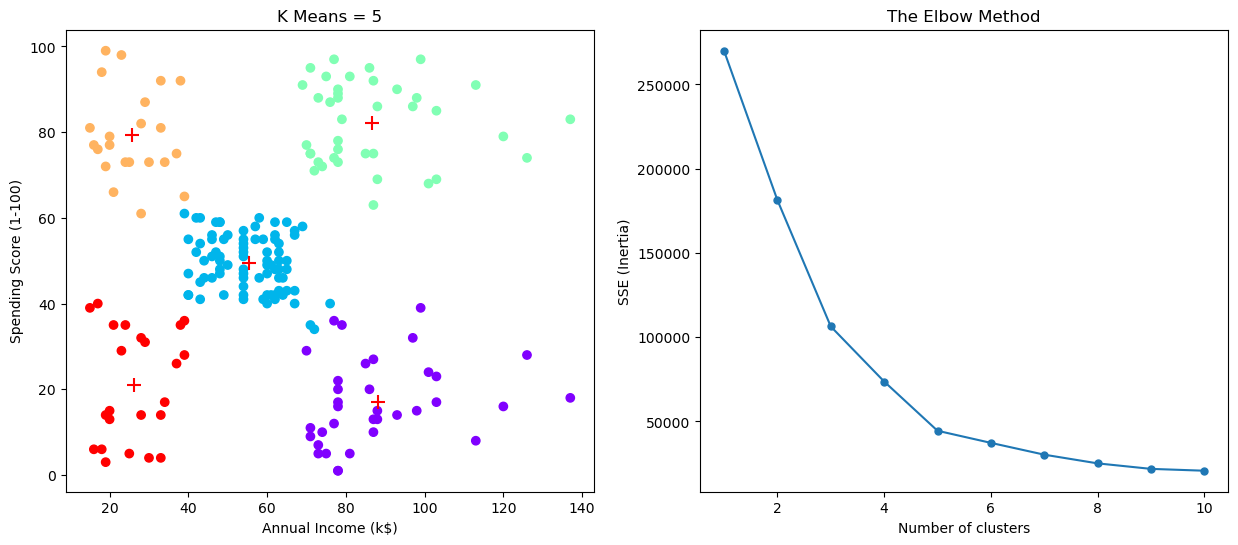

In [28]:
f, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(15,6))

ax1.set_title('K Means = 5')
ax1.scatter(x[:,0],x[:,1],c=model5.labels_,cmap='rainbow')
ax1.scatter(model5.cluster_centers_[:, 0], model5.cluster_centers_[:, 1], color='red', marker='+', s=100)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')


ax2.set_title('The Elbow Method')
ax2.plot(range(1, 11), scores, marker = '.',markersize=10)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('SSE (Inertia)')

## Step 7: Evaluation Criteria for Clustering Models:
#### 1. Inertia (Within-Cluster Sum of Squares)
- Sum of squared distances from each point to its assigned cluster centroid.
- Lower the score, the better.
- Caution: This score always decreases with more clusters, so don't use alone to choose k.

#### 2. Silhouette Score
- Measures how similar a point is to its own cluster (cohesion) vs. other clusters (separation).
- Values range from -1 (bad clustering) to 1 (prefect clustering) where 0 means overlapping clusters and 0.5 means good clustering.
- Higher, closer to 1, score is better.
- $ SS = \frac{1}{n} \sum \frac {(b - a)}{max(a, b)}$ where, a is the average distance of the data point to all other data points in the same cluster and b is minimum average distance of the data point to all other data points in any other cluster. 

#### 3. Calinski-Harabasz Index (Variance Ratio Criterion)
- A ratio of between-cluster dispersion to within-cluster dispersion.
- Higher scores are better.

#### 4. Davies-Bouldin Index
- The average similarity between each cluster (intra-cluster distance) and its most similar one (inter-cluster distance).
- Lower scores (close to 0) are better (compact, well-seperated clusters) vs higher scores (indicating overlapping and spread out clusters).
- $ DBI = \frac{1}{k} \sum \limits ^{k} _{j=1} max ( \frac{S_{i} + S_{j}}{M_{ij}}) $

Where:
- 𝑘 = number of clusters
- $𝑆_{𝑖}$ = average distance of all points in cluster 𝑖 to its centroid (cluster compactness)
- $𝑀_{𝑖𝑗}$ = distance between the centroids of clusters 𝑖 and 𝑗 (cluster separation)

For each cluster 𝑖, find the "worst-case" cluster 𝑗
(most similar = least well separated), then average these worst-case values over all clusters.


In [30]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
labels = model6.labels_
print("Inertia:", model6.inertia_)
print("Silhouette Score:", silhouette_score(x, labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(x, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(x, labels))

Inertia: 37265.86520484345
Silhouette Score: 0.5379675585622219
Calinski-Harabasz Index: 242.29567848269156
Davies-Bouldin Index: 0.6588591430377728


In [58]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
labels = model5.labels_
print("Inertia:", model5.inertia_)
print("Silhouette Score:", silhouette_score(x, labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(x, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(x, labels))

Inertia: 44448.45544793369
Silhouette Score: 0.553931997444648
Calinski-Harabasz Index: 247.35899338037282
Davies-Bouldin Index: 0.5725628995597087


---
Follow-Up Thoughts:

1. What could we now do with this information? 
2. Five was determined to be the 'optimum' number of clusters, is this the only possible solution for this problem?
---